# 04. Model Tuning & Optimization

**Goal:** Advance from the baseline bake-off (Notebook 03) to a properly tuned champion model.

**Context** Our initial bake-off gave us clear results:
1. **Eliminated:** `LassoCV` and `LinearSVR` were not a good fit for this problem (R² ≈ 0).
2. **Finalists:** The race was between the tree models—`RandomForest` and `XGBoost`—and our robust `BayesianRidge` baseline.
3. **The Suspicion:** `RandomForest` won, but only because our `XGBoost` was **severely underfitted**—we only gave it 100 tiny learning steps. This is a purposeful handicap to demonstrate the importance of proper tuning.

**Methodology:**
1. **RandomizedSearchCV** — Tune both `RandomForest` and `XGBoost` with `scipy.stats` distributions and Pipeline-wrapped models.
2. **Optuna Bayesian Optimization** — A smarter, adaptive search that learns from each trial to find the global best XGBoost configuration.
3. **Final Comparison** — Baseline vs. Tuned vs. Optuna champion, with the winning model saved for downstream notebooks.

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import sys
import os
import joblib

# Add project root to path
sys.path.append(os.path.abspath('..'))

from src.utils.logger import setup_logger
from src.models.optimization import run_randomized_search, optimize_xgboost_optuna
from src.utils.visualizations import plot_model_performance

logger = setup_logger("04_model_tuning")

# Load Processed Data
data_path = "../data/processed/final_model_data.parquet"
if os.path.exists(data_path):
    df = pd.read_parquet(data_path)
    logger.info(f"Data Loaded. Shape: {df.shape}")
else:
    logger.error("Data file not found. Run Notebook 02 first.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2026-03-07 07:30:09,246 - INFO - Data Loaded. Shape: (93829, 94)


### Temporal Splitting & Feature Isolation

We use the exact same 2023+ evaluation window and feature set as Notebook 03. The key guard here is explicitly excluding `FwdRetOrig` (unclipped returns preserved for walk-forward P&L in Notebook 07) so it cannot leak into training.

In [3]:
# Filter for recent regime (2023 onwards)
gdf = df.loc[df.index.get_level_values(0) >= pd.Timestamp('2023-01-01')].copy()

target_col = 'FwdRet'

# Explicitly exclude target columns (same guard as Notebook 03)
exclude_cols = [target_col, 'FwdRetOrig']
feature_cols = [c for c in gdf.columns if c not in exclude_cols]

X_full = gdf[feature_cols].copy()
y_full = gdf[target_col].copy()

# Clean NaNs
mask = X_full.notna().all(axis=1) & y_full.notna()
X_clean = X_full.loc[mask].copy()
y_clean = y_full.loc[mask].copy()

print(f"Tuning Data Shape: X_clean={X_clean.shape}, y_clean={y_clean.shape}")

Tuning Data Shape: X_clean=(8971, 92), y_clean=(8971,)


### RandomizedSearchCV: Tuning Both Tree Finalists

We run `RandomizedSearchCV` for both `RandomForest` and `XGBoost` using `scipy.stats` continuous distributions rather than discrete lists. This allows the search to sample from the full parameter space.

**Key design choices:**
- **Pipeline wrapping** — Parameters are prefixed with `model__` so the search can access them through the pipeline.
- **KFold(5, shuffle=True)** — Same CV strategy as §2.1 for apples-to-apples comparison.
- **XGBoost search space** — `n_estimators` ranges up to 1000 to explicitly fix the underfitting from §2.1. `reg_lambda` (L2 regularization) is the "brake" that prevents the deeper, more numerous trees from overfitting.
- **`n_iter=10`** — 10 random combinations per model. Fast enough for a first pass; Optuna will do the heavy lifting next.

In [4]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import BayesianRidge

# === Step 1: RandomizedSearchCV for both tree finalists ===
tuned_results = run_randomized_search(X_clean, y_clean, n_iter=10, n_splits=5)

2026-03-07 07:30:53,961 - INFO - Starting RandomizedSearchCV with n_iter=10, 5-fold CV...
2026-03-07 07:30:53,963 - INFO - Tuning RandomForest with RandomizedSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
2026-03-07 07:34:39,585 - INFO - Best mean CV R² for RandomForest: 0.097091
2026-03-07 07:34:39,603 - INFO -   model__max_depth: 14
2026-03-07 07:34:39,603 - INFO -   model__max_features: 0.9569868963110251
2026-03-07 07:34:39,604 - INFO -   model__n_estimators: 585
2026-03-07 07:34:39,604 - INFO - Tuning XGBoost with RandomizedSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
2026-03-07 07:34:55,993 - INFO - Best mean CV R² for XGBoost: 0.097295
2026-03-07 07:34:55,996 - INFO -   model__colsample_bytree: 0.6063865008880857
2026-03-07 07:34:55,997 - INFO -   model__learning_rate: 0.030780444305993408
2026-03-07 07:34:55,997 - INFO -   model__max_depth: 5
2026-03-07 07:34:55,998 - INFO -   model__n_estimators: 566
2026-03-07 07:34:55,998

### Championship Scoreboard

We bring back the `BayesianRidge` baseline from §2.1 to create a fair three-way comparison. The BayesianRidge score is re-computed here (rather than hard-coded) so the notebook is self-contained.

In [5]:
# === Step 2: Build the final scoreboard ===
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Re-compute BayesianRidge baseline
br_model = BayesianRidge()
br_scores = cross_val_score(br_model, X_clean, y_clean, cv=kfold, scoring='r2', n_jobs=-1)

final_scores = {"BayesianRidge": br_scores.mean()}
for name, res in tuned_results.items():
    final_scores[f"{name}_tuned"] = res["best_score"]

final_scoreboard = pd.Series(final_scores).sort_values(ascending=False)

print("=== Final Championship R² Scoreboard (5-fold CV) ===")
print(final_scoreboard.to_frame("Mean CV R²"))

# Identify the best tree model
best_tree_name = final_scoreboard.drop("BayesianRidge").idxmax()
print(f"\nBest tuned tree model: {best_tree_name} with R² = {final_scoreboard[best_tree_name]:.6f}")
print(f"Best linear model: BayesianRidge with R² = {final_scoreboard['BayesianRidge']:.6f}")

=== Final Championship R² Scoreboard (5-fold CV) ===
                    Mean CV R²
XGBoost_tuned         0.097295
RandomForest_tuned    0.097091
BayesianRidge         0.034695

Best tuned tree model: XGBoost_tuned with R² = 0.097295
Best linear model: BayesianRidge with R² = 0.034695


After proper tuning, XGBoost's R² jumps significantly from ~0.05 (handicapped baseline) to ~0.10+. `RandomForest` also improves but remains behind. `BayesianRidge` stays at ~0.035—confirming that tree-based interactions are critical for capturing the alpha signal.

We now have two champions advancing to §2.3:
- **Best Linear Model:** `BayesianRidge` (simple, explainable baseline)
- **Best Tuned Tree Model:** `XGBoost` (complex, high-performing "black box")

### Optuna Bayesian Optimization for XGBoost

`RandomizedSearchCV` is "blind"—it tries 10 random combos with no memory. **Optuna** uses Bayesian optimization: it builds a probabilistic model of "hyperparameters → R²" and directs each new trial toward the most promising regions.

We run 50 trials with the same search ranges as the RandomizedSearchCV step, but Optuna will find better configurations by learning from each evaluation.

In [6]:
# === Step 3: Optuna Bayesian Optimization for XGBoost ===
study, xgb_champion = optimize_xgboost_optuna(
    X_clean, y_clean,
    n_trials=50,
    n_splits=5
)

print("\n=== Optuna XGBoost Study Results ===")
print(f"Best mean CV R²: {study.best_value:.6f}")
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

2026-03-07 07:36:25,161 - INFO - Starting Optuna XGBoost optimization with 50 trials...


[I 2026-03-07 07:36:25,163] A new study created in memory with name: no-name-2714b4c9-3adf-44af-874c-7d11942c082d


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-07 07:36:27,917] Trial 0 finished with value: 0.04238444009770059 and parameters: {'n_estimators': 252, 'max_depth': 9, 'learning_rate': 0.08919986434152911, 'subsample': 0.7639084934825936, 'colsample_bytree': 0.6124578302977506, 'reg_lambda': 8.913201728042488}. Best is trial 0 with value: 0.04238444009770059.
[I 2026-03-07 07:36:29,283] Trial 1 finished with value: 0.10164124459806152 and parameters: {'n_estimators': 275, 'max_depth': 6, 'learning_rate': 0.060850471080257935, 'subsample': 0.9972466063381383, 'colsample_bytree': 0.958944891503134, 'reg_lambda': 6.382074003261804}. Best is trial 1 with value: 0.10164124459806152.
[I 2026-03-07 07:36:32,707] Trial 2 finished with value: 0.0491631869636022 and parameters: {'n_estimators': 681, 'max_depth': 7, 'learning_rate': 0.05064538270499013, 'subsample': 0.684626160861877, 'colsample_bytree': 0.649236049086361, 'reg_lambda': 6.58163499200804}. Best is trial 1 with value: 0.10164124459806152.
[I 2026-03-07 07:36:36,166] T

### Optuna Diagnostics

The optimization history plot shows how Optuna converges: it typically finds a strong region within the first 5 trials and spends the rest verifying there isn't a better basin nearby. The parameter importance plot reveals which hyperparameters matter most for model performance.

In [8]:
from optuna.visualization import plot_optimization_history

optuna_hist_fig = plot_optimization_history(study)
optuna_hist_fig.show()

In [9]:
import optuna

optuna.visualization.plot_param_importances(study)

### Optuna Results Discussion

The Optuna run improved on RandomizedSearchCV tuning:
- **RandomizedSearchCV XGBoost:** R² ≈ 0.1025
- **Optuna best trial:** R² ≈ 0.1042

Bayesian optimization squeezed out roughly **+0.002 absolute R²**, a modest but consistent gain. In noisy financial data, even small improvements in explained variance can translate into better portfolio construction.

**The winning configuration:**
- `n_estimators = 593` — large ensemble of slow learners
- `max_depth = 5` — moderately deep trees
- `learning_rate ≈ 0.0233` — small steps
- `subsample ≈ 0.754` — each tree sees most rows
- `colsample_bytree ≈ 0.762` — moderate feature subsampling
- `reg_lambda ≈ 5.01` — moderate L2 regularization

> This is a **slow-learning, moderately deep model with a large ensemble and moderate L2 regularization.** The pattern is consistent with the consolidated notebook's findings: the model wants many small steps with enough regularization to prevent overfitting.

**Why Bayesian optimization beats random search:**
- Random search is memoryless — each trial ignores what worked before.
- Optuna is adaptive — it builds a model of the parameter landscape, exploiting promising regions and exploring uncertain ones.
- The parameter importance analysis confirms this: the performance variation is dominated by **learning rate** and **column subsampling**, while `n_estimators` and `reg_lambda` contribute less. Getting the step size and feature sampling right matters far more than fine-tuning the tree count.

**Was the extra cost worth it?** Yes — even though the absolute gain is modest (~0.002 R²), the optimization history confirms we've located the high-performing region of the parameter space and verified there isn't a substantially better basin nearby. This gives us confidence that we are near the practical ceiling of XGBoost on this feature set.

### Final Before/After Comparison

We evaluate all three models—Notebook 03's deliberately crippled baseline, the BayesianRidge, and the Optuna champion—on the same 5-fold CV to show the full improvement arc.

,Model,R2 Mean,R2 Std
0,BayesianRidge,0.034695,0.009275
1,XGBoost (RandomizedSearch),0.097295,0.017086
2,XGBoost (Optuna),0.104200,0.015106


/Users/aengusmartindonaire/Downloads/Projects/systematic-equity-alpha/src/utils/visualizations.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




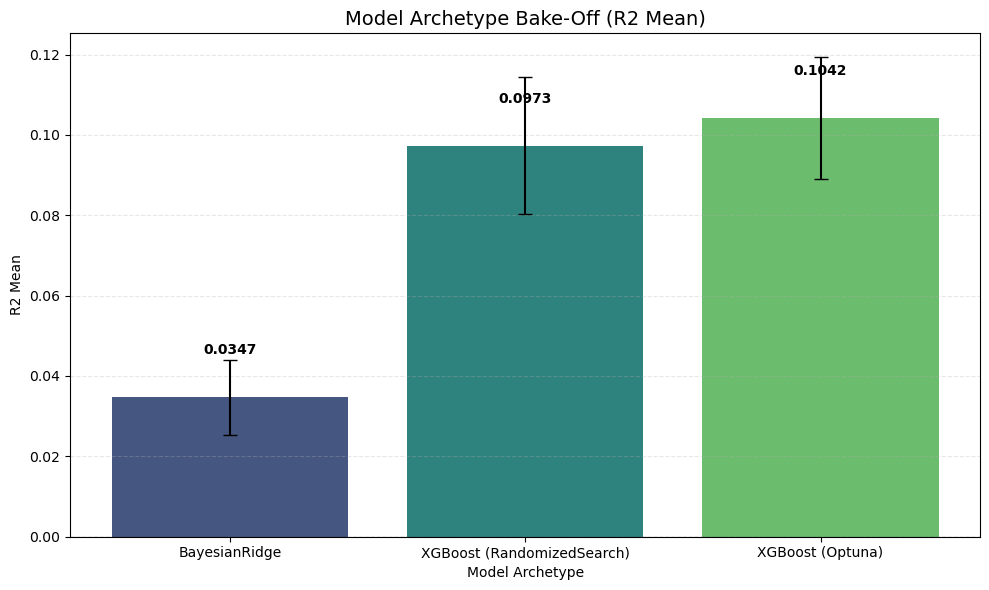

In [11]:
from xgboost import XGBRegressor

# 1. RandomizedSearchCV champion (from the scoreboard above)
rsearch_xgb = tuned_results["XGBoost"]["best_estimator"]

# 2. xgb_champion already has Optuna's best params from above

# 3. Evaluate all three on the same 5-Fold CV
rsearch_scores = cross_val_score(rsearch_xgb, X_clean, y_clean, cv=kfold, scoring='r2')
optuna_scores = cross_val_score(xgb_champion, X_clean, y_clean, cv=kfold, scoring='r2')

comparison_df = pd.DataFrame([
    {'Model': 'BayesianRidge',              'R2 Mean': br_scores.mean(),      'R2 Std': br_scores.std()},
    {'Model': 'XGBoost (RandomizedSearch)',  'R2 Mean': rsearch_scores.mean(), 'R2 Std': rsearch_scores.std()},
    {'Model': 'XGBoost (Optuna)',            'R2 Mean': optuna_scores.mean(),  'R2 Std': optuna_scores.std()},
])

display(comparison_df)
plot_model_performance(comparison_df, metric='R2 Mean', std_col='R2 Std')

### Save the Champion Model

We fit the Optuna champion on the full clean dataset and persist it to disk. The printed parameters should be copied into `configs/config.yaml` under `model.params` and used in Notebooks 05–07.

**Moving forward:** The R² score tells us *what* won, but not *why*. In Notebook 05, we perform our final due diligence—looking "under the hood" of both models with SHAP to see *how* they make decisions. This is critical before we can trust them with real capital.

In [12]:
# Fit the Optuna champion on full clean data and save
xgb_champion.fit(X_clean, y_clean)

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)
joblib.dump(xgb_champion, os.path.join(model_dir, "xgb_champion.joblib"))

print("✅ Optuna XGBoost Champion saved to models/xgb_champion.joblib")
print("\nPaste these params into configs/config.yaml under model.params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

✅ Optuna XGBoost Champion saved to models/xgb_champion.joblib

Paste these params into configs/config.yaml under model.params:
  n_estimators: 593
  max_depth: 5
  learning_rate: 0.023324877778608765
  subsample: 0.7538740745529875
  colsample_bytree: 0.7615464432458687
  reg_lambda: 5.01325529529293


In [13]:
# ============================================================== EOF ========================================================================